# Chronic Kidney Disease (CKD) — Classification Notebook

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import joblib

## 2. قراءة الداتا

**ملاحظة:** حط ملف `chronic kidney disease.csv` في نفس فولدر النوتبوك قبل ما تشغل الخلية دي.

In [2]:
df = pd.read_csv('chronic kidney disease.csv')

df.shape

(400, 14)

In [3]:
df.head()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [4]:
df['Class'].value_counts()

,count
Class,
1,250
0,150


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,76.455000,1.017712,1.015000,0.395000,0.882500,57.40550,3.07235,137.529025,4.627850,12.526900,8406.090000,4.708275,0.369350,0.625000
std,13.476536,0.005434,1.272329,1.040038,0.322418,49.28597,5.61749,9.204273,2.819783,2.716171,2523.219976,0.840315,0.482023,0.484729
min,50.000000,1.005000,0.000000,0.000000,0.000000,1.50000,0.40000,4.500000,2.500000,3.100000,2200.000000,2.100000,0.000000,0.000000
25%,70.000000,1.015000,0.000000,0.000000,1.000000,27.00000,0.90000,135.000000,4.000000,10.875000,6975.000000,4.500000,0.000000,0.000000
50%,78.000000,1.020000,1.000000,0.000000,1.000000,44.00000,1.40000,137.530000,4.630000,12.530000,8406.000000,4.710000,0.000000,1.000000
75%,80.000000,1.020000,2.000000,0.000000,1.000000,61.75000,3.07000,141.000000,4.800000,14.625000,9400.000000,5.100000,1.000000,1.000000
max,180.000000,1.025000,5.000000,5.000000,1.000000,391.00000,76.00000,163.000000,47.000000,17.800000,26400.000000,8.000000,1.000000,1.000000


## 3. EDA

### 3.1 توزيع الـ Target

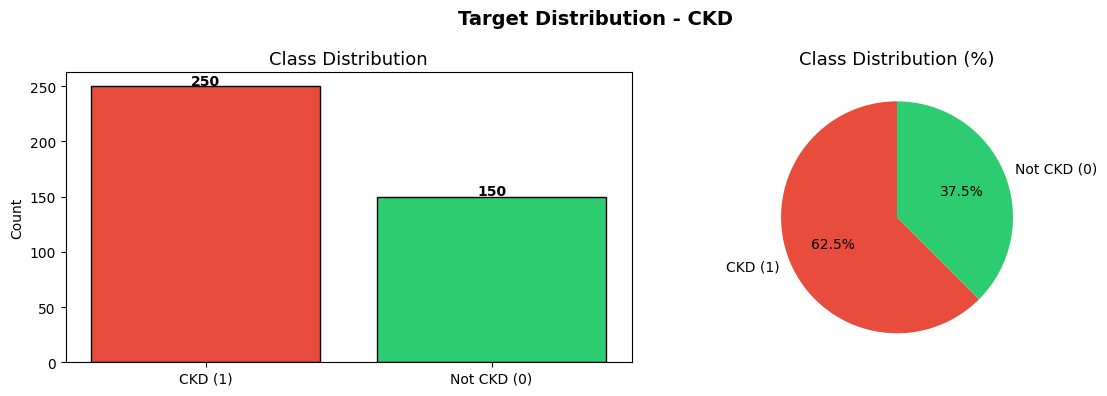

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Class'].value_counts()
axes[0].bar(['CKD (1)', 'Not CKD (0)'], counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['CKD (1)', 'Not CKD (0)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13)
plt.suptitle('Target Distribution - CKD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 توزيع كل feature حسب الـ Class

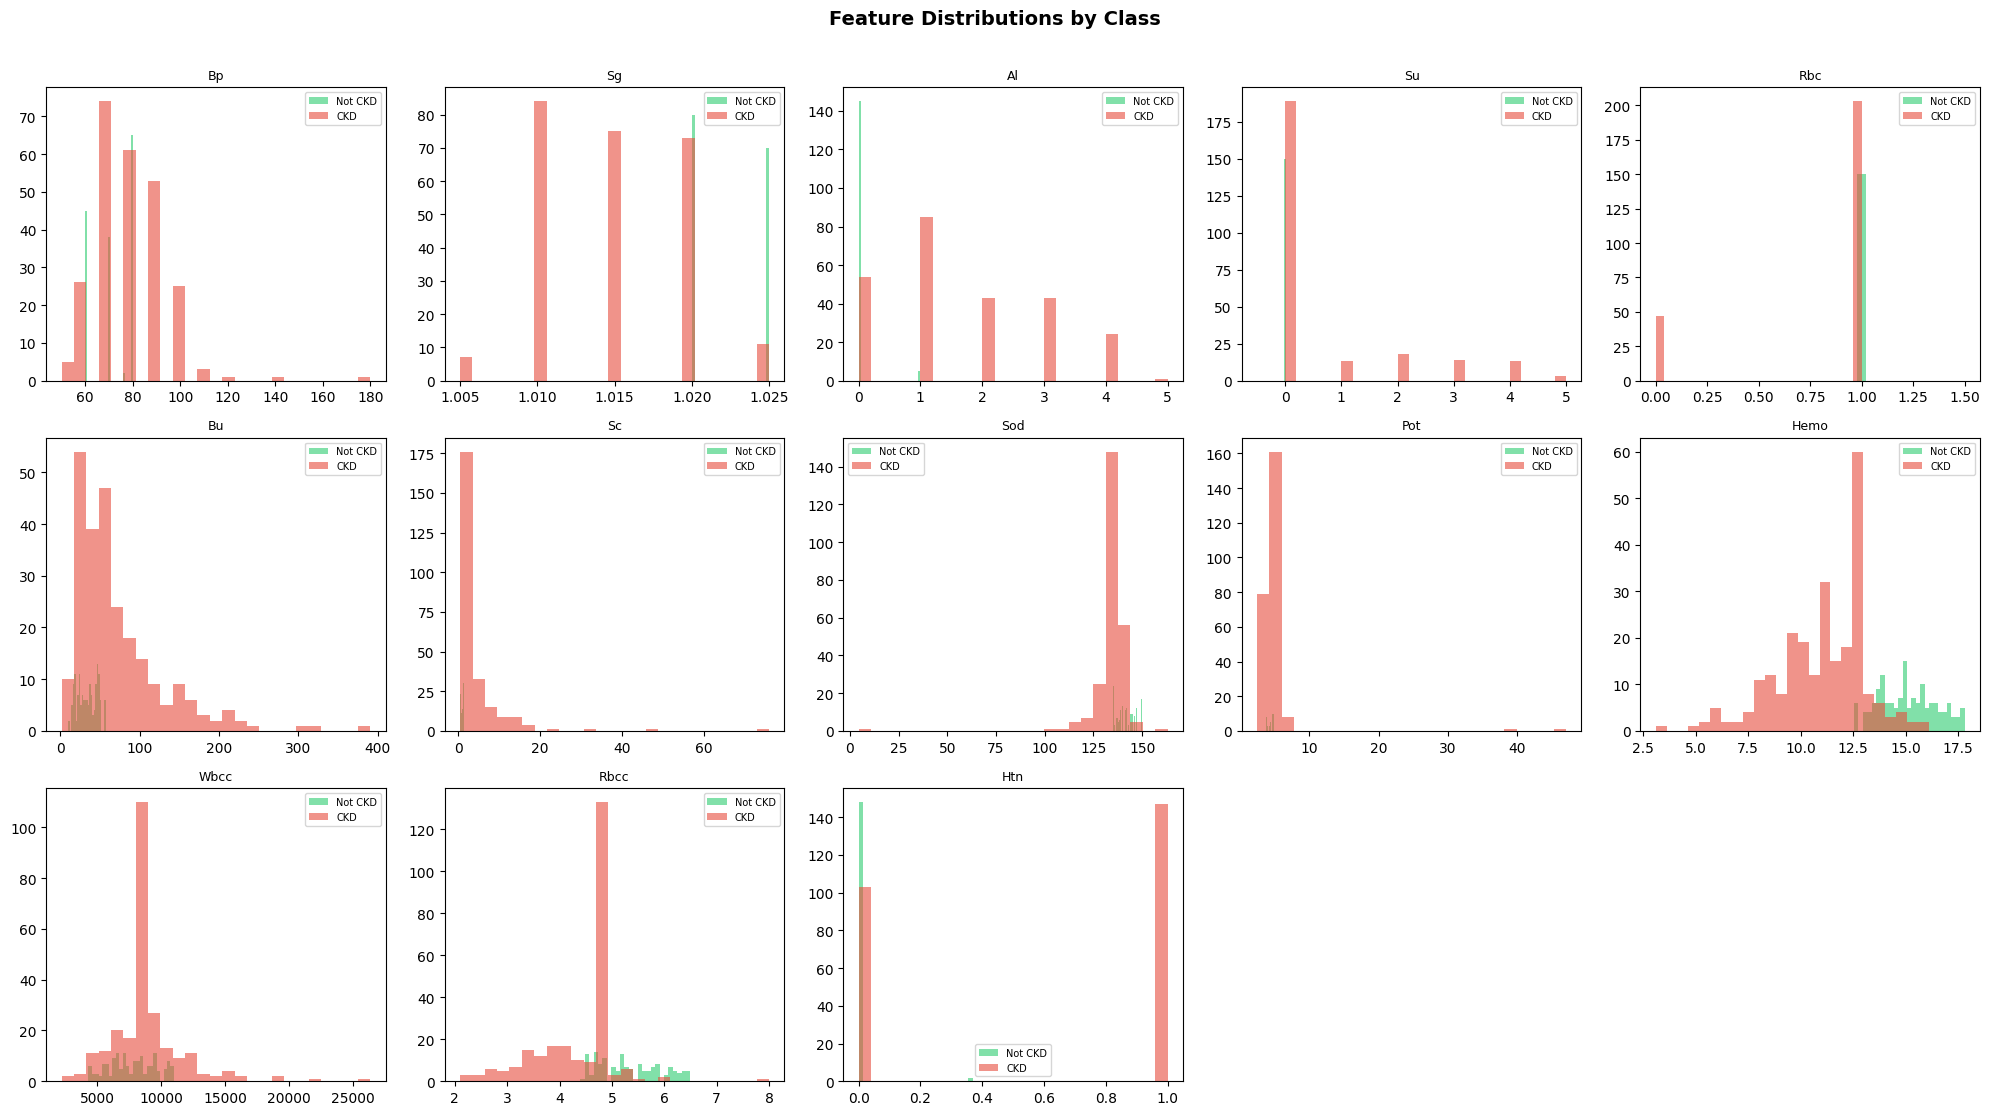

In [8]:
features = [c for c in df.columns if c != 'Class']
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(features):
    for cls, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Not CKD', 'CKD']):
        axes[i].hist(df[df['Class'] == cls][col].dropna(), bins=25, alpha=0.6, color=color, label=label)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Boxplots

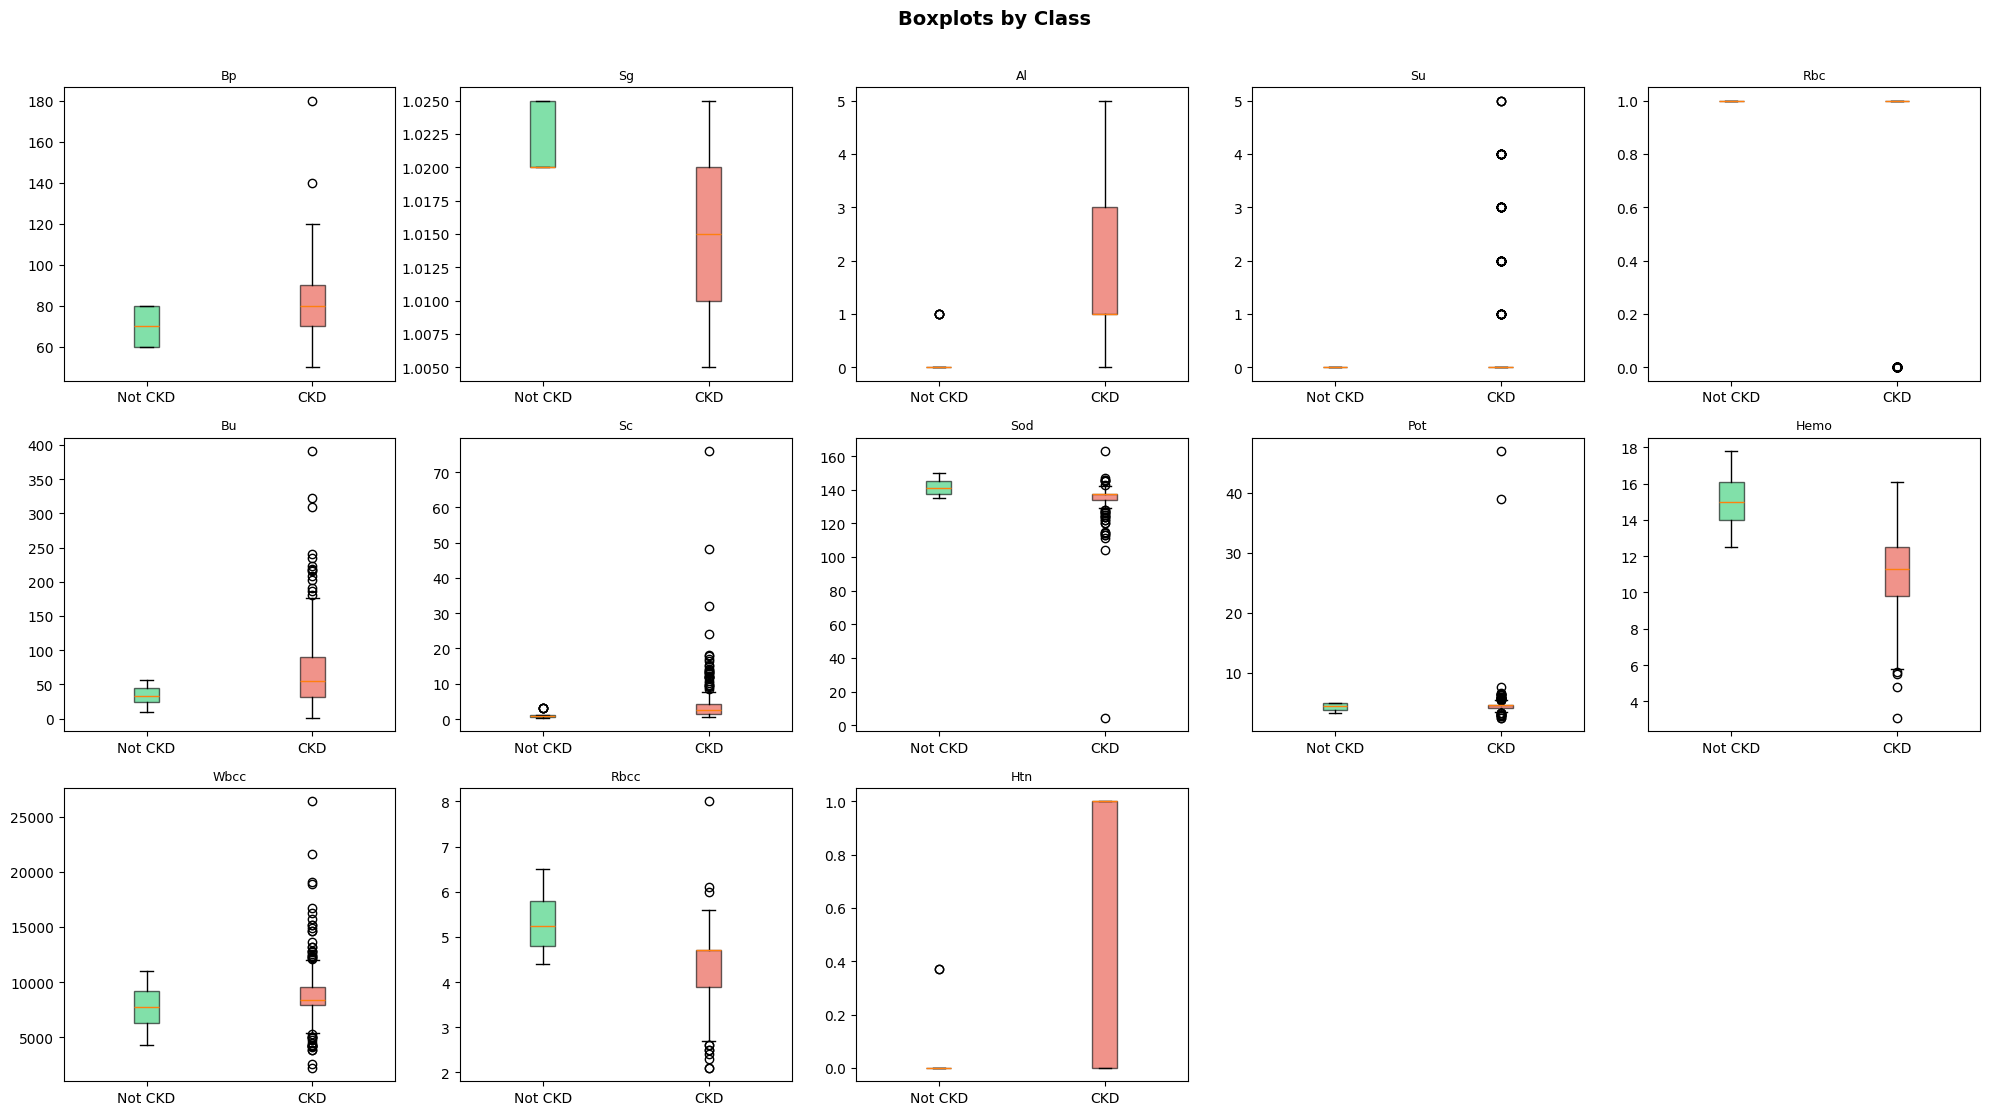

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(features):
    data = [df[df['Class'] == cls][col].dropna() for cls in [0, 1]]
    bp = axes[i].boxplot(data, labels=['Not CKD', 'CKD'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    axes[i].set_title(col, fontsize=9)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

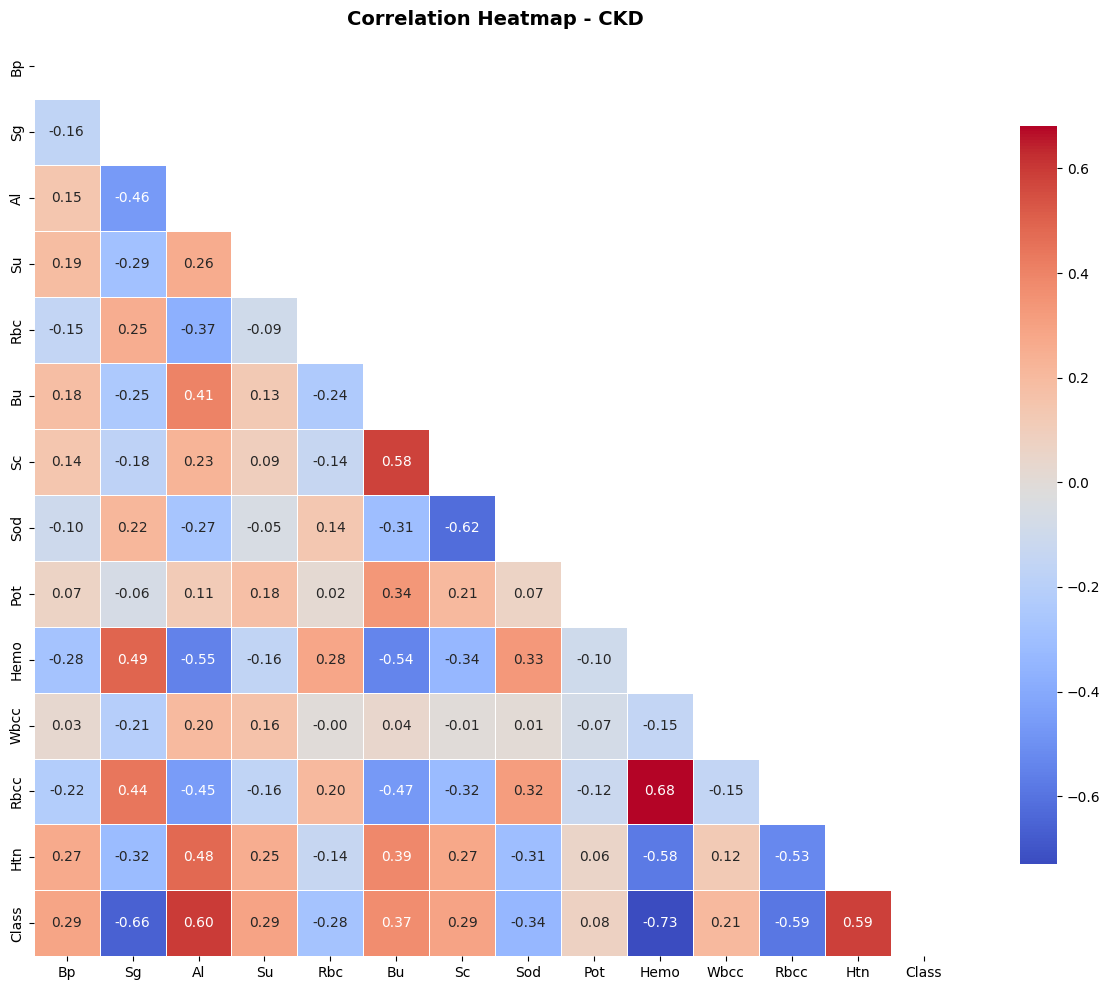

In [10]:
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - CKD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('obesity_eda_distribution.png', dpi=300)
plt.show()

### 3.5 Correlation مع الـ Target

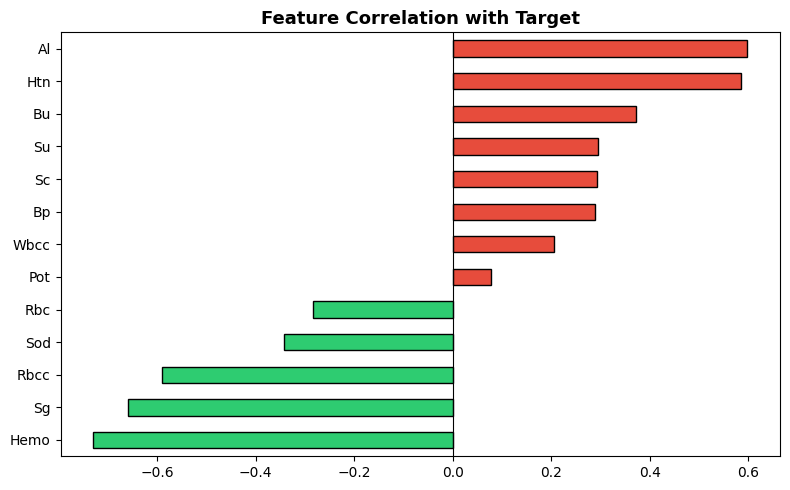

In [11]:
target_corr = df.corr()['Class'].drop('Class').sort_values()
colors_c = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr]
plt.figure(figsize=(8, 5))
target_corr.plot(kind='barh', color=colors_c, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing + Pipeline

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, '| Test:', X_test.shape)

ratio = (y_train == 0).sum() / (y_train == 1).sum()

pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(n_estimators=200, random_state=42,
                                eval_metric='logloss', scale_pos_weight=ratio))
    ])
}

Train: (320, 13) | Test: (80, 13)


## 5. Cross Validation

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('\n--- Cross Validation (5-Fold) ---')
cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = scores
    print('%s: %.4f ± %.4f' % (name, scores.mean(), scores.std()))


--- Cross Validation (5-Fold) ---
Logistic Regression: 0.9821 ± 0.0196
Random Forest: 0.9877 ± 0.0110
XGBoost: 0.9800 ± 0.0127


### 5.1 رسم نتائج الـ Cross Validation

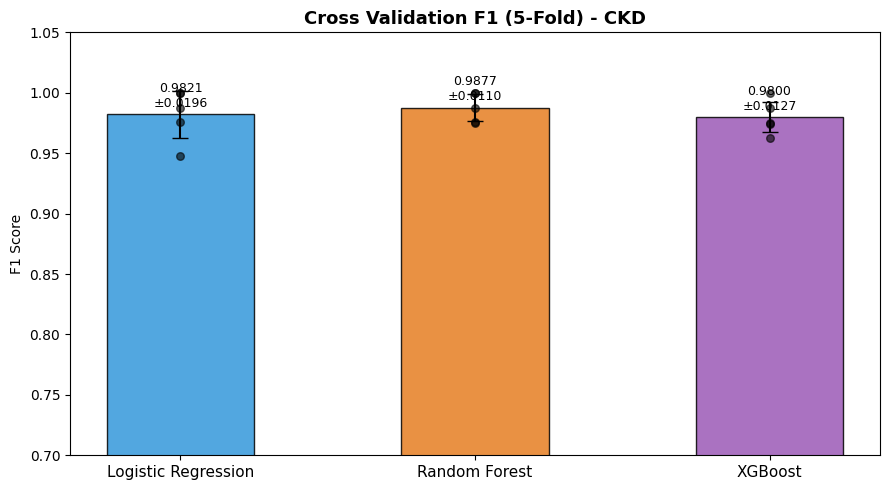

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
names_cv  = list(cv_results.keys())
means     = [cv_results[n].mean() for n in names_cv]
stds      = [cv_results[n].std()  for n in names_cv]
colors_cv = ['#3498db', '#e67e22', '#9b59b6']
x = np.arange(len(names_cv))
bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors_cv,
              alpha=0.85, width=0.5, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(names_cv, fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_title('Cross Validation F1 (5-Fold) - CKD', fontsize=13, fontweight='bold')
ax.set_ylim(0.7, 1.05)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
            '%.4f\n±%.4f' % (mean, std), ha='center', fontsize=9)
for i, n in enumerate(names_cv):
    ax.scatter([i]*5, cv_results[n], color='black', zorder=5, s=30, alpha=0.6)
plt.tight_layout()
plt.show()

## 6. تدريب الموديلات + اختيار الأفضل أوتوماتيك

In [15]:
results    = []
best_model = None
best_name  = None
best_f1    = 0
all_preds  = {}
all_probas = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    all_preds[name]  = pred
    all_probas[name] = proba

    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    auc  = roc_auc_score(y_test, proba)

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1':        round(f1,   4),
        'AUC':       round(auc,  4)
    })

    if f1 > best_f1:
        best_f1    = f1
        best_model = pipe
        best_name  = name

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print('\n--- Model Comparison ---')
print(results_df.to_string(index=False))
print('\nBest Model:', best_name)
print('Best F1:  ', best_f1)


--- Model Comparison ---
              Model  Accuracy  Precision  Recall     F1    AUC
      Random Forest     1.000       1.00    1.00 1.0000 1.0000
            XGBoost     0.975       0.98    0.98 0.9800 0.9987
Logistic Regression     0.975       1.00    0.96 0.9796 0.9973

Best Model: Random Forest
Best F1:   1.0


## 7. Confusion Matrices

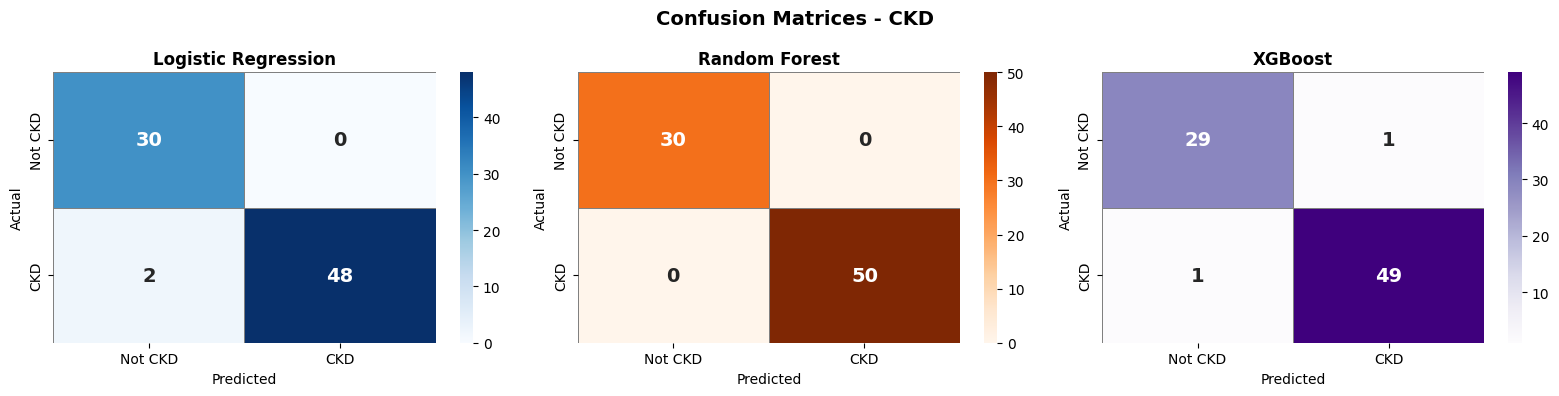

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_cm = ['Blues', 'Oranges', 'Purples']
for ax, (name, pred), cmap in zip(axes, all_preds.items(), colors_cm):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'],
                linewidths=0.5, linecolor='gray',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
plt.suptitle('Confusion Matrices - CKD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. ROC Curve

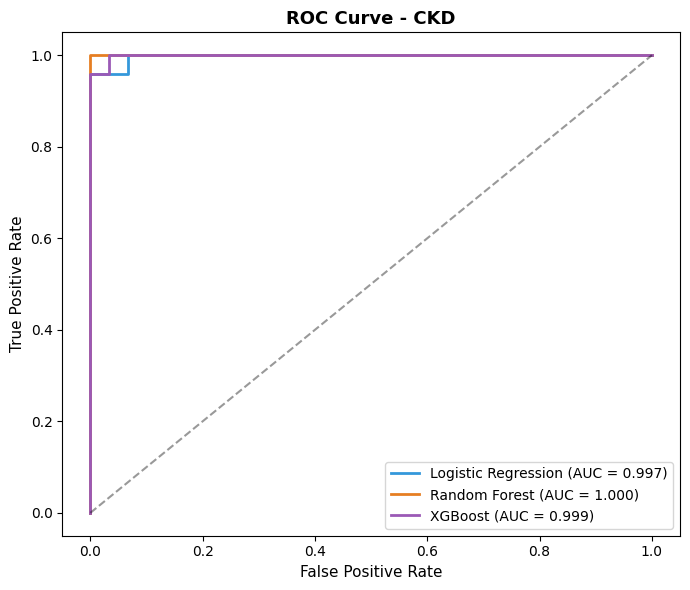

In [17]:
plt.figure(figsize=(7, 6))
colors_roc = ['#3498db', '#e67e22', '#9b59b6']
for (name, proba), color in zip(all_probas.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label='%s (AUC = %.3f)' % (name, auc))
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve - CKD', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Precision-Recall Curve

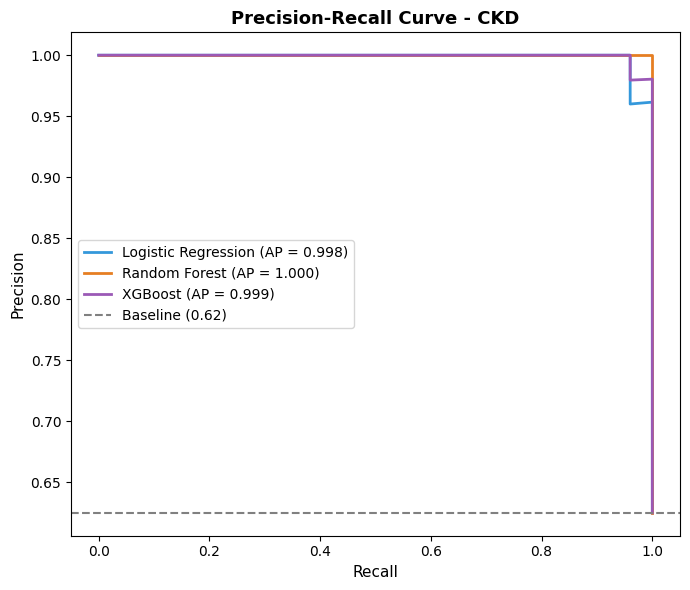

In [18]:
plt.figure(figsize=(7, 6))
for (name, proba), color in zip(all_probas.items(), colors_roc):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, color=color, linewidth=2,
             label='%s (AP = %.3f)' % (name, ap))
baseline = y_test.sum() / len(y_test)
plt.axhline(baseline, color='gray', linestyle='--',
            label='Baseline (%.2f)' % baseline)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve - CKD', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. مقارنة الـ Metrics

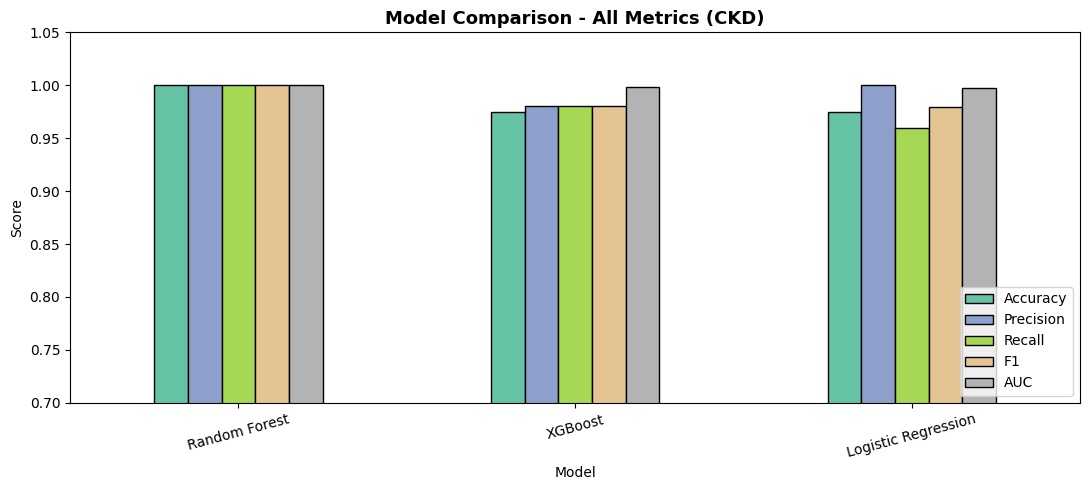

In [19]:
metrics_df = results_df.set_index('Model')[['Accuracy','Precision','Recall','F1','AUC']]
metrics_df.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison - All Metrics (CKD)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15, fontsize=10)
plt.ylim(0.7, 1.05)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 11. Feature Importance

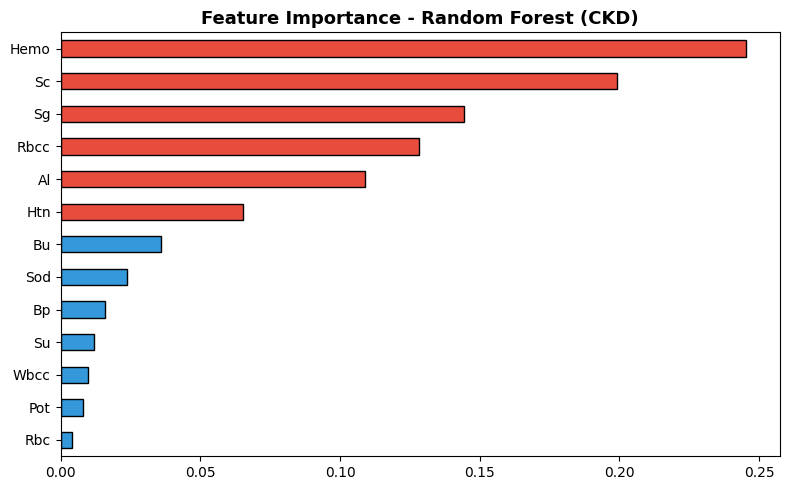

In [20]:
best_rf_model = pipelines['Random Forest'].named_steps['model']
importance = pd.Series(best_rf_model.feature_importances_, index=X.columns).sort_values()
colors_fi  = ['#e74c3c' if v > importance.median() else '#3498db' for v in importance]
plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color=colors_fi, edgecolor='black')
plt.title('Feature Importance - Random Forest (CKD)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Learning Curve

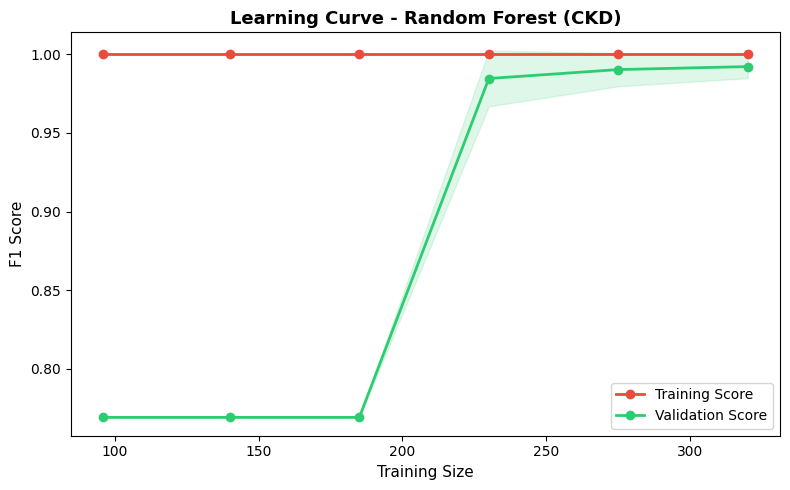

In [21]:
best_pipe_for_lc = pipelines[best_name]
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe_for_lc, X, y,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.3, 1.0, 6),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', linewidth=2, label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, val_mean, 'o-', color='#2ecc71', linewidth=2, label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#2ecc71')
plt.xlabel('Training Size', fontsize=11)
plt.ylabel('F1 Score', fontsize=11)
plt.title('Learning Curve - %s (CKD)' % best_name, fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 13. حفظ الموديل

In [22]:
joblib.dump(best_model, 'best_ckd_model.pkl')
print('\nModel saved: best_ckd_model.pkl')
print('Best Model:', best_name, '| F1:', best_f1)


Model saved: best_ckd_model.pkl
Best Model: Random Forest | F1: 1.0
